In [1]:
import pandas as pd
data = pd.read_csv("p2c-attempts-v1.csv").replace('A01', 1).replace('A02', 2).replace('A03', 3)
data.dtypes

student            int64
assignment         int64
attempt            int64
grade              int64
submission time    int64
dtype: object

In [2]:
#data3 = data2.sort_values("student")
data2 = data.sort_values(['student', 'assignment', "attempt"])
data2.head(10)

,student,assignment,attempt,grade,submission time
1082,10133,1,1,85,35
1442,10133,1,2,81,32
385,10133,1,3,81,34
627,10133,1,4,97,35
1923,10133,1,5,88,7
984,10133,2,1,50,32
1231,10133,2,2,96,32
1877,10133,3,1,81,4
1909,10133,3,2,100,2
457,10406,1,1,74,48


In [3]:
df = data2
df

,student,assignment,attempt,grade,submission time
1082,10133,1,1,85,35
1442,10133,1,2,81,32
385,10133,1,3,81,34
627,10133,1,4,97,35
1923,10133,1,5,88,7
...,...,...,...,...,...
342,99140,2,1,85,-97
638,99140,2,2,72,-99
1591,99140,2,3,98,-99
633,99858,1,1,76,-39


In [4]:
# Define Late Submission Weight (LSW) and Grade Improvement Weight (GIW)
LSW = 0.6
GIW = 0.4

# Initialize an empty list to store the procrastination index for each row
procrastination_index_list = []
PA_list = []
GIA_list = []

# Iterate through the DataFrame row by row using numerical index
for i in range(len(df)):
    current_row = df.iloc[i]
    current_submission_time = current_row['submission time']
    current_grade = current_row['grade']
    current_attempt = current_row['attempt']
    #print(current_attempt)
    # Accessing the previous row using the numerical index (i - 1)
    if i > 0:
        previous_row = df.iloc[i - 1]
        previous_submission_time = previous_row['submission time']
        previous_grade = previous_row['grade']

        # Calculate Procrastination Attempt (PA) and Grade Improvement Attempt (GIA)
        PA = 1 if current_submission_time < 0 else 0
        GIA = 1 if previous_grade >= current_grade or current_attempt == 1 else 0
        
        PA_list.append(PA)
        GIA_list.append(GIA)
        
        # Calculate Procrastination Index (PI) for the current row
        PI = (LSW * PA) + (GIW * GIA)
        procrastination_index_list.append(PI)
    else:
        procrastination_index_list.append(0.4)  # The first row does not have a previous row
        PA_list.append(0)
        GIA_list.append(1)
        
# Add the procrastination index list as a new column in the DataFrame
df['PA'] = PA_list
df['GIA'] = GIA_list
df['procras_index'] = procrastination_index_list

# Display the result
print(df)

      student  assignment  attempt  grade  submission time  PA  GIA  \
1082    10133           1        1     85               35   0    1   
1442    10133           1        2     81               32   0    1   
385     10133           1        3     81               34   0    1   
627     10133           1        4     97               35   0    0   
1923    10133           1        5     88                7   0    1   
...       ...         ...      ...    ...              ...  ..  ...   
342     99140           2        1     85              -97   1    1   
638     99140           2        2     72              -99   1    1   
1591    99140           2        3     98              -99   1    0   
633     99858           1        1     76              -39   1    1   
2       99858           2        1     18              -40   1    1   

      procras_index  
1082            0.4  
1442            0.4  
385             0.4  
627             0.0  
1923            0.4  
...            

In [5]:
# more p: late submission and no grade improvement
# less p: early sub and grade improvement

In [6]:
df2 = df.drop(columns = ["student", "PA", "GIA"])
df2

,assignment,attempt,grade,submission time,procras_index
1082,1,1,85,35,0.4
1442,1,2,81,32,0.4
385,1,3,81,34,0.4
627,1,4,97,35,0.0
1923,1,5,88,7,0.4
...,...,...,...,...,...
342,2,1,85,-97,1.0
638,2,2,72,-99,1.0
1591,2,3,98,-99,0.6
633,1,1,76,-39,1.0


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming 'df' is the DataFrame with the data
X = df[['assignment', 'attempt', 'grade', 'submission time']]#.values
y = df['procras_index']#.values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
# Make predictions on the test data
y_pred = rf_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error (MSE) and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared:", r2)

Mean Squared Error (MSE): 0.01287053269412072
R-squared: 0.8733387337420709


In [26]:
import time
import numpy as np

start_time = time.time()
importances = rf_model.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.025 seconds


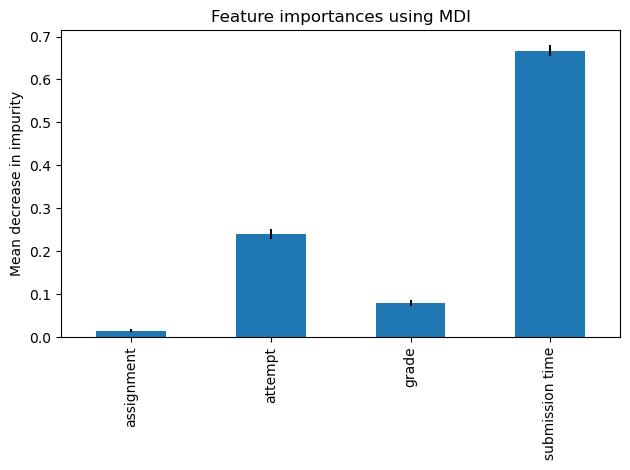

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

forest_importances = pd.Series(importances, index=['assignment', 'attempt', 'grade', 'submission time'])

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()